In [1]:
from trainer import Clicker
from datasets.hqseg44k import HQSeg44KTrainDataset
import numpy as np
import matplotlib.pyplot as plt

/home/clc/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = HQSeg44KTrainDataset(data_root='data/sam-hq')

In [3]:
image, mask, instances_info = dataset[400]
clicker = Clicker(num_random_clicks=1)
# print type of mask
clicker.set_gt_mask(mask.reshape(256, 256))

In [4]:
_, eroded_mask, dt = clicker.init_clicks()

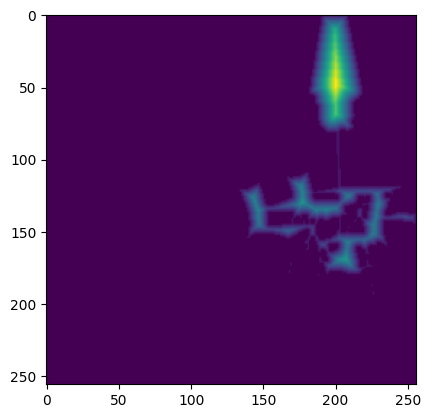

In [5]:
plt.imshow(dt)

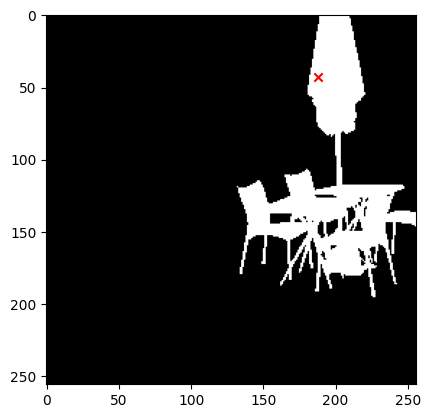

In [6]:
plt.imshow(mask.reshape(256, 256), cmap='gray')

click_list = clicker.click_list

pos_clicks = [click for click in click_list if click[2] == 1]
neg_clicks = [click for click in click_list if click[2] == 0]

plt.scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
plt.scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')

plt.show()

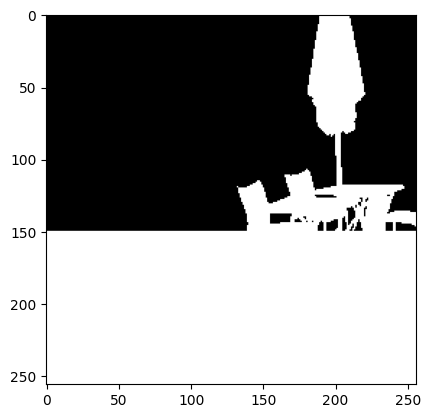

In [ ]:
pred_mask = mask.copy()
pred_mask[150:, :, :] = 1
plt.imshow(pred_mask, cmap='gray')
plt.show()

In [ ]:
clicker.predict_next_click(pred_mask.reshape(256, 256))

(202, 52, 0)

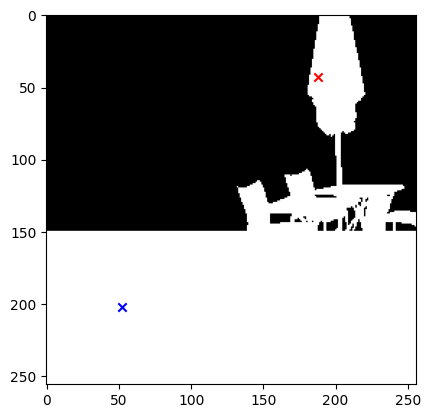

In [9]:
plt.imshow(pred_mask, cmap='gray')
click_list = clicker.click_list
pos_clicks = [click for click in click_list if click[2] == 1]
neg_clicks = [click for click in click_list if click[2] == 0]
plt.scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
plt.scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')
plt.show()

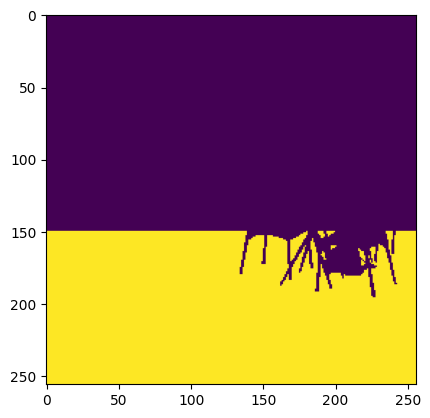

In [10]:
plt.imshow(np.logical_xor(mask.reshape(256, 256), pred_mask.reshape(256, 256)))
plt.show()

In [11]:
clicker.to_sam_format(pad_size=10)

(tensor([[ 43., 188.],
         [202.,  52.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.],
         [  0.,   0.]]),
 tensor([ 1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]))